# Experimento A/B en página de inicio

El objetivo de este proyecto es evaluar un **experimento A/B** realizado en una página de inicio (landing page) con versiónes **A y B** para apoyar una **decisión de negocio basada en datos**.

---

El archivo `landing_experiment.csv` contiene información de usuarios expuestos a dos versiones de la página de inicio (landing page) dentro del experimento A/B. Incluye región, dispositivo, fuente de tráfico, tipo de usuario, conversión y gasto.

El análisis sigue una lógica clara y progresiva:

1. 🔍 Explorar y validar los datos.

2. 💰 Comparar el **gasto promedio** por usuario entre la página A y B.

3. 🎯 Comparar la **tasa de conversión** entre la página A y B.

4. 🌐 Revisar **la relación entre la fuente de tráfico y la conversión**.

5. 👤 Revisar **la relación entre el tipo de usuario y la conversión**.

6. 📈 **Visualizar los resultados**: Respalda tus conclusiones mediante gráficos claros.

Se aplican **puebas estadísticas apropiados** para comparar las páginas y **recomendar qué versión es mejor**, justificando la decisión con datos.

## 🧩 Paso 1: Cargar y validar los datos

### 1.1 Carga de datos y vista rápida

In [1]:
# importar librerías
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# cargar archivo
df = pd.read_csv('/datasets/landing_experiment.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   user_id         40000 non-null  object 
 1   date            40000 non-null  object 
 2   landing         40000 non-null  object 
 3   region          40000 non-null  object 
 4   dispositivo     40000 non-null  object 
 5   traffic_source  40000 non-null  object 
 6   user_type       40000 non-null  object 
 7   converted       40000 non-null  int64  
 8   gasto           40000 non-null  float64
dtypes: float64(1), int64(1), object(7)
memory usage: 2.7+ MB


**Vista previa e información general del conjunto de datos**

In [3]:
# mostrar las primeras 5 filas
df.head(5)

,user_id,date,landing,region,dispositivo,traffic_source,user_type,converted,gasto
0,26f3052e-8500-44ea-8fff-06de65258abb,2026-01-01,A,Norte,Mobile,Email,Recurrente,1,38.08
1,92378c09-4bbf-40c7-945e-82b84f392d22,2026-01-23,A,Occidente,Mobile,Organic,Nuevo,0,0.00
2,a4397360-40e5-45d6-a7ff-dcb4da2c9a1f,2026-01-01,B,Centro,Mobile,Organic,Nuevo,0,0.00
3,7ca3a26f-1e6c-44aa-9b09-b8cb01112956,2026-01-22,A,Centro,Mobile,Ads,Nuevo,0,0.00
4,8dc9593b-5b9c-479d-848b-a99493920419,2026-01-16,A,Sur,Mobile,Organic,Nuevo,0,0.00


In [4]:
# información general
print(df['landing'].value_counts())
print()
print(df.describe())

B    20018
A    19982
Name: landing, dtype: int64

         converted         gasto
count  40000.00000  40000.000000
mean       0.14265      9.325554
std        0.34972     25.667986
min        0.00000      0.000000
25%        0.00000      0.000000
50%        0.00000      0.000000
75%        0.00000      0.000000
max        1.00000    303.680000


- En el dataset no se observan valores nulos en las columnas, y los tipos de datos son correctos (converted como int64, gasto como float64).

- El experimento muestra un equilibrio entre las versiones A (19,982 usuarios, 49.95%) y B (20,018 usuarios, 50.05%), lo que permite realizar comparaciones en ambos grupos.

- La tasa de conversión general es del 14.27% (la otra parte de los usuarios no convirtió, por lo que su gasto es 0). Esto indica que los percentiles 25%, 50% y 75% de gasto son cero quiere decirt que la mayoría de usuarios no generó ningún gasto.

- El dataset no tiene valores ausentes ni errores de tipo de dato, se puede continuar con el análisis sin necesidad de limpieza adicional.

**Descripción del conjunto de datos**

El dataset contiene las siguientes columnas:

- `user_id` — Identificador único del usuario
- `date` — Fecha en la que el usuario fue expuesto a la página
- `landing` — Versión de la página mostrada al usuario
- `region` — Región geográfica del usuario
- `dispositivo` — Tipo de dispositivo utilizado por el usuario
- `traffic_source` — Canal por el que llegó el usuario
- `user_type` — Tipo de usuario según historial previo
- `converted` — Indica si el usuario realizó una conversión
- `gasto` — Monto gastado por el usuario (0 si no convirtió)

### 1.2 Análisis exploratorio y revisión de calidad de datos

Se identifican las variables clave del experimento A/B y se valida que estén bien definidas, completas y que sean consistentes.


 **Variable `user_id`**  
 Verificar usuarios únicos

In [5]:
print(f"Total de filas: {len(df)}")
print(f"Usuarios únicos: {df['user_id'].nunique()}")
print(f"Duplicados: {df['user_id'].duplicated().sum()}")

Total de filas: 40000
Usuarios únicos: 40000
Duplicados: 0


 **Variable `date`**  
Explorar rango de fechas

In [6]:
# Resumen estadístico
df["date"].describe()

count          40000
unique            28
top       2026-01-24
freq            1512
Name: date, dtype: object

In [7]:
# Identificar rango temporal del experimento
print("Fecha mínima:", df["date"].min())
print("Fecha máxima:", df["date"].max())

Fecha mínima: 2026-01-01
Fecha máxima: 2026-01-28


**Variable `gasto` (numérica)**

In [8]:
# Resumen estadístico
df["gasto"].describe()

count    40000.000000
mean         9.325554
std         25.667986
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        303.680000
Name: gasto, dtype: float64

In [9]:
# Resumen estadístico de usuarios que se convirtieron
df[df["converted"] == 1]["gasto"].describe()

count    5706.000000
mean       65.373668
std        30.896545
min        12.120000
25%        42.950000
50%        59.860000
75%        80.370000
max       303.680000
Name: gasto, dtype: float64

 **Variables categóricas**  
 Verificar categorías esperadas del experimento ( A y B).

In [10]:
# Explorar variables categóricas y cómo se distribuyen
print("\nConteo de categorías:")
print(df["landing"].value_counts())


Conteo de categorías:
B    20018
A    19982
Name: landing, dtype: int64


In [11]:
print("Región:")
print(df["region"].value_counts())

print("\nDispositivo:")
print(df["dispositivo"].value_counts())

print("\nFuente de tráfico:")
print(df["traffic_source"].value_counts())

print("\nTipo de usuario:")
print(df["user_type"].value_counts())

Región:
Norte        11166
Centro        9613
Sur           8039
Occidente     6398
Oriente       4784
Name: region, dtype: int64

Dispositivo:
Mobile     24829
Desktop    15171
Name: dispositivo, dtype: int64

Fuente de tráfico:
Organic     17987
Ads         11935
Email        6123
Referral     3955
Name: traffic_source, dtype: int64

Tipo de usuario:
Nuevo         26033
Recurrente    13967
Name: user_type, dtype: int64


✍️ **Comentario**: Haz doble clic en este bloque y escribe qué ves
- Si hay errores como categorías mal escritas, define pasos a seguir. Por ejemplo:
    - Hay valores negativos/no esperados en la columna X.
- Si no hay errores señalalo y continúa con el proceso. Por ejemplo:
    - Todas las columnas tienen valores esperados.

Comienza a escribir debajo de este texto, una vez escritas tus conclusiones, **elimina estas instrucciones** (de aqui hacia arriba de este bloque) para dejar solamente tus hallazgos.

- No se identificaron errores en las variables del experimento.

- user_id: 40,000 usuarios únicos, sin duplicados. Los usuarios aparecen exactamente una vez, esto confirma que la unidad de análisis es correcta.

- date: el experimento se ejecutó entre el 2026-01-01 y el 2026-01-28.

- gasto: al revisar solo usuarios convertidos 5,706 de 40,000, equivalente a la tasa de conversión de 14.27% (previamente analizado), el gasto promedio real es de 65.37, con un rango entre 12.12 y 303.68. Lo que indica que el promedio general es de 9.33 (calculado sobre todos los usuarios).


- Variables categóricas: todas las columnas (landing, region, dispositivo, traffic_source, user_type) presentan únicamente las categorías esperadas, sin errores de escritura, valores negativos ni categorías inesperadas.

- Todas las columnas contienen valores esperados.

## 💰 Paso 2: Comparar el gasto promedio por usuario (página A vs B)

Se evalua si existen diferencias estadísticamente significativas en el gasto promedio de los **usuarios que se convirtieron en clientes** entre la página A y la página B, para identificar qué versión genera **mayor valor económico** para el negocio.


In [12]:
# Gasto por versión
gasto_A = df[(df['landing'] == 'A') & (df['converted'] == 1)]['gasto']
gasto_B = df[(df['landing'] == 'B') & (df['converted'] == 1)]['gasto']

# Verificar cantidad de datos que tiene cada grupo
len(gasto_A), len(gasto_B)

(2512, 3194)

In [13]:
print("Gasto - Página A:")
print(gasto_A.describe())

print("\nGasto - Página B:")
print(gasto_B.describe())

Gasto - Página A:
count    2512.000000
mean       61.086572
std        28.875470
min        12.120000
25%        40.612500
50%        55.840000
75%        74.837500
max       303.680000
Name: gasto, dtype: float64

Gasto - Página B:
count    3194.00000
mean       68.74536
std        32.00102
min        12.98000
25%        45.21000
50%        62.57000
75%        84.27750
max       249.99000
Name: gasto, dtype: float64


### Prueba T

**Hipótesis:**

- **Hipótesis nula (H₀):** No existe una diferencia significativa en el gasto promedio por usuario convertido entre la página A y la página B.
  
- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en el gasto promedio por usuario convertido entre la página A y la página B.

In [14]:
# Aplicar prueba
t_stat, p_value = ttest_ind(gasto_A, gasto_B)

# Visualizar resultados
print(f"Estadístico : {t_stat:.3f}")
print(f"Valor p: {p_value:.3f}")

Estadístico : -9.366
Valor p: 0.000


In [15]:
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de una diferencia significativa en el gasto promedio.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de una diferencia en el gasto promedio.")

Rechazamos la hipótesis nula: hay evidencia de una diferencia significativa en el gasto promedio.


In [16]:
print(f"Gasto promedio página A: {gasto_A.mean():.2f}")
print(f"Gasto promedio página B: {gasto_B.mean():.2f}")
print(f"Diferencia: {gasto_A.mean() - gasto_B.mean():.2f}")

Gasto promedio página A: 61.09
Gasto promedio página B: 68.75
Diferencia: -7.66



### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Se rechaza la hipótesis nula, ya que el valor p (0.000) es menor al umbral de significancia de 0.05. Se muestra evidencia de que hay una diferencia significativa en el gasto promedio por usuario  convertido entre la página A y la página B.


**Interpretación de negocio:**  
Explica con tus propias palabras qué indican estos resultados sobre el gasto promedio entre la página A y la página B.

Los usuarios que se convirtieron en clientes a través de la página B, gastaron en promedio 68.75 mientras que los de la página A gastaron 61.09 una diferencia de 7.66 por usuario a favor de la página B.

El estadístico t negativo (-9.366) confirma que la página B tiene el promedio más alto (al restar A - B, el resultado es negativo porque B es mayor). Por el tamaño de la muestra (2,512 y 3,194 usuarios) y que el monto del valor p es bajo, esta diferencia es una señal clara y confiable.

Desde la perspectiva de negocio, esto sugiere que la página B no solo podría generar más conversiones, sino que además los usuarios que si se convierten a través de ella gastan más en promedio. Esto representa una ventaja económica potencial si se decide implementar la página B: más usuarios convertidos y mayor valor por transacción.

Es importante recordar que este resultado está relacionado dentro del experimento controlado A/B, por lo que la diferencia observada se atribuye al diseño de la página, por lo que la asignación a los grupos fue aleatoria.

---


## 📈 Paso 3: Comparar la tasa de conversión entre la página A y B

Se evalua si existen difere]ncias estadísticamente significativas en la **tasa de conversión** entre la página A y B, con el fin de identificar qué versión genera **mayor número de usuarios convertidos**.

### Prueba Z

**Hipótesis:**

- **Hipótesis nula (H₀):** No existe una diferencia significativa en la tasa de conversión entre la página A y la página B.

- **Hipótesis alternativa (H₁):** Existe una diferencia significativa en la tasa de conversión entre la página A y la página B.

In [17]:
# Número de usuarios convertidos por página

conversiones_A = df[df['landing'] == 'A']['converted'].sum()
conversiones_B = df[df['landing'] == 'B']['converted'].sum()

# Total de usuarios por página

total_A = df[df['landing'] == 'A']['converted'].count()
total_B = df[df['landing'] == 'B']['converted'].count()

print("Usuarios convertidos por página:\n", f"A: {conversiones_A}, B: {conversiones_B}")
print("\nTotal de usuarios por página:\n", f"A: {total_A}, B: {total_B}")


Usuarios convertidos por página:
 A: 2512, B: 3194

Total de usuarios por página:
 A: 19982, B: 20018


In [18]:
conteos = [conversiones_A, conversiones_B]
num_observaciones = [total_A, total_B]

print(f"Éxitos: {conteos}")
print(f"Totales: {num_observaciones}")

Éxitos: [2512, 3194]
Totales: [19982, 20018]


In [19]:
# Aplicar prueba

z_stat, p_value = proportions_ztest(conteos, num_observaciones)

# Visualizar resultados
print(f"Estadístico : {z_stat:.3f}")
print(f"Valor p: {p_value:.3f}")

Estadístico : -9.677
Valor p: 0.000


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Se rechaza la hipótesis nula, ya que el valor p (0.000) es menor al umbral de significancia de 0.05. Existe evidencia de que hay una diferencia significativa en la tasa de conversión entre la página A y la página B.

**Interpretación de negocio:**  
Explica qué indica el resultado sobre la tasa de conversión entre la página A y la página B.

La página B tiene una tasa de conversión del 15.96%, frente al 12.57% de la página A  una diferencia de aproximadamente 3.4 puntos porcentuales a favor de la página B.

El estadístico z negativo (-9.677) y el valor p extremadamente bajo confirman que esta diferencia es significativa y con una razón de ser, dado el gran tamaño de muestra de ambos grupos (19,982 y 20,018 usuarios).

La evidencia  apunta consistentemente a que la página B es superior en métricas clave, convierte a más usuarios y estos gastan más en promedio. Esto representa una recomendación preliminar sólida para implementar la página B.

## 🔗 Paso 4: Revisar la relación entre la fuente de tráfico y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre la **fuente de tráfico** (`traffic_source`) y la **conversión** (`converted`), para identificar qué canales generan más conversiones.

### Prueba Chi cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):**  No existe una asociación significativa entre la fuente de tráfico y la conversión.
- **Hipótesis alternativa (H₁):** Existe una asociación significativa entre la fuente de tráfico y la conversión.

In [20]:
tabla_trafico = pd.crosstab(df['traffic_source'], df['converted'])
print(tabla_trafico)

converted           0     1
traffic_source             
Ads             10176  1759
Email            5205   918
Organic         15507  2480
Referral         3406   549


In [21]:
# Aplicar prueba
chi2_stat, p_value, dof, expected = chi2_contingency(tabla_trafico)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor p: {p_value:.3f}")
print(f"Grados de libertad: {dof}")

Estadístico chi-cuadrado: 8.662
Valor p: 0.034
Grados de libertad: 3


In [22]:
alpha = 0.05
if p_value < alpha:
    print("Rechazamos la hipótesis nula: hay evidencia de asociación entre la fuente de tráfico y la conversión.")
else:
    print("No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre la fuente de tráfico y la conversión.")

print()

tabla_normalizada = pd.crosstab(df['traffic_source'], df['converted'], normalize='index') * 100
print(tabla_normalizada)

Rechazamos la hipótesis nula: hay evidencia de asociación entre la fuente de tráfico y la conversión.

converted               0          1
traffic_source                      
Ads             85.261835  14.738165
Email           85.007349  14.992651
Organic         86.212264  13.787736
Referral        86.118837  13.881163


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

Se rechaza la hipótesis nula, ya que el valor p (0.034) es menor al umbral de significancia de 0.05, existe registro de asociación entre la fuente de tráfico y la conversión, aunque el valor p está relativamente cerca del umbral, por lo que la evidencia es significativa pero no fuerte.

**Interpretación de negocio:**  
Explica qué indican los resultados considerando tanto las cantidades absolutas como las tasas de conversión.

Aunque la prueba chi cuadrada confirma que existe una asociación significativa entre el canal de tráfico y la conversión. Las diferencias son pequeñas en ya que van del 13.79% Organic al 14.99% Email, con una diferencia de  apenas 1.2 puntos porcentuales entre el canal más débil y el más fuerte.

Email y Ads muestran las tasas de conversión más altas con un porcentaje del 14.99% y 14.74%, mientras que Organic y Referral quedan por debajo con un 13.79% y 13.88%.

Se recomienda no sobreestimar este hallazgo, el canal de tráfico no es un factor decisivo en la conversión, pero si un factor para priorizar inversión en Email y Ads sobre Organic y Referral, si el negocio desea optimizar los canales. 

## 👤 Paso 5: Revisar la relación entre el tipo de usuario y la conversión

Se analiza si existe una **asociación estadísticamente significativa** entre el **tipo de usuario** (`user_type`) y la **conversión** (`converted`), entendiendo que un usuario recurrente puede haber visitado antes sin necesariamente convertirse en cliente en esta ocasión.

El objetivo es identificar qué perfiles muestran mayor probabilidad de conversión dentro del contexto analizado.

### Prueba Chi cuadrada

**Hipótesis:**
- **Hipótesis nula (H₀):** No existe una asociación significativa entre el tipo de usuario y la conversión.
- **Hipótesis alternativa (H₁):** Existe una asociación significativa entre el tipo de usuario y la conversión.

In [23]:
tabla_usuario = pd.crosstab(df['user_type'], df['converted'])
print(tabla_usuario)

converted       0     1
user_type              
Nuevo       22295  3738
Recurrente  11999  1968


In [24]:
tabla_usuario_normalizada = pd.crosstab(df['user_type'], df['converted'], normalize='index') * 100
print(tabla_usuario_normalizada)

converted           0          1
user_type                       
Nuevo       85.641301  14.358699
Recurrente  85.909644  14.090356


In [25]:
# Aplicar prueba

chi2_stat, p_value, dof, expected = chi2_contingency(tabla_usuario)

print(f"Estadístico chi-cuadrado: {chi2_stat:.3f}")
print(f"Valor p: {p_value:.3f}")
print(f"Grados de libertad: {dof}")

alpha = 0.05
if p_value < alpha:
    print("\nRechazamos la hipótesis nula: hay evidencia de asociación entre el tipo de usuario y la conversión.")
else:
    print("\nNo rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre el tipo de usuario y la conversión.")


Estadístico chi-cuadrado: 0.513
Valor p: 0.474
Grados de libertad: 1

No rechazamos la hipótesis nula: no hay evidencia suficiente de asociación entre el tipo de usuario y la conversión.


### 📝 Conclusión e interpretación

**Decisión:**  
(¿Se rechaza o no la hipótesis nula?)

No se rechaza la hipótesis nula, ya que el valor p 0.474 es mayor al umbral de significancia de 0.05. No hay evidencia para afirmar que existe una asociación entre el tipo de usuario y la conversión.

**Interpretación de negocio:**  
Explica qué indica el resultado.

Las tasas de conversión entre usuarios nuevos 14.36% y recurrentes 14.09% son números parecidos con una diferencia de apenas 0.27 puntos porcentuales, que la prueba estadística confirma como no significativa con un valor p = 0.474, muy por encima del umbral de 0.05.

Esto indica que aunque un usuario sea nuevo o recurrente no influye en su probabilidad de convertirse en cliente. Esta prueba no muestra ningún patrón que sugiera tratar a estos dos segmentos de forma diferenciada en cuanto a estrategias de conversión.

Desde la perspectiva de negocio, esto sugiere que no es prioridad personalizar la landing page o las campañas según si el usuario es nuevo o recurrente. 

## 📊 Paso 6: Visualizar los resultados de variables categóricas

Se explora visualmente la relación entre variables categóricas (`traffic_source` y `user_type`) y la conversión, mostrando para cada categoría:
- la cantidad absoluta de usuarios que convirtieron y no convirtieron,
- la proporción de usuarios que convirtieron y no convirtieron.

Esto permite analizar tanto el impacto en volumen como la efectividad relativa de cada categoría y reforzar los resultados obtenidos en las pruebas estadísticas.

### Relación entre la fuente de tráfico y la conversión

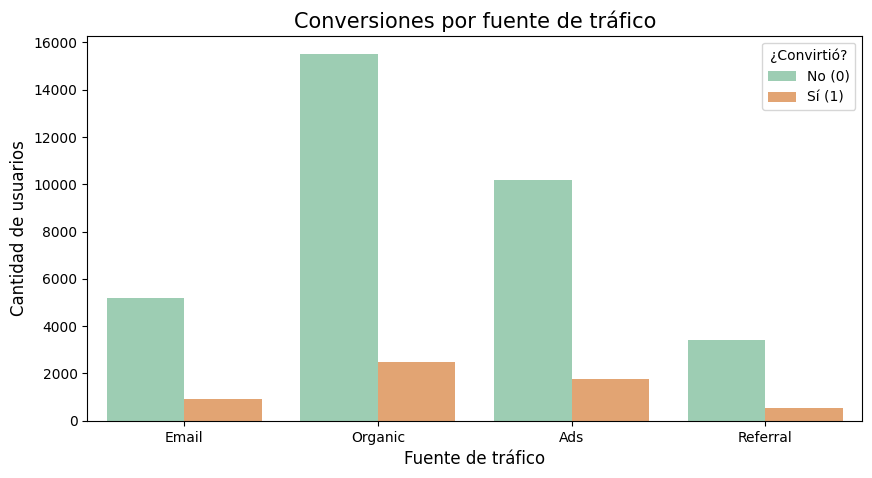

In [31]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='traffic_source', hue='converted', palette=["#95D5B2", "#F4A261"])
plt.title('Conversiones por fuente de tráfico', fontsize=15)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

El gráfico de 'Conversiones por fuente de tráfico', muestra el volumen absoluto de usuarios por canal. Organic es,la fuente de tráfico con más usuarios cerca de 18,000, seguido de Ads con 12,000 usuarios, Email 6,000 usuarios, y Referral 4,000 usuarios, como el canal más pequeño. 
En los cuatro canales, la barra de 'No convirtió', domina ampliamente sobre la de 'Sí convirtió', lo cual es esperable dado que la tasa general de conversión del experimento es de apenas 14.27%.

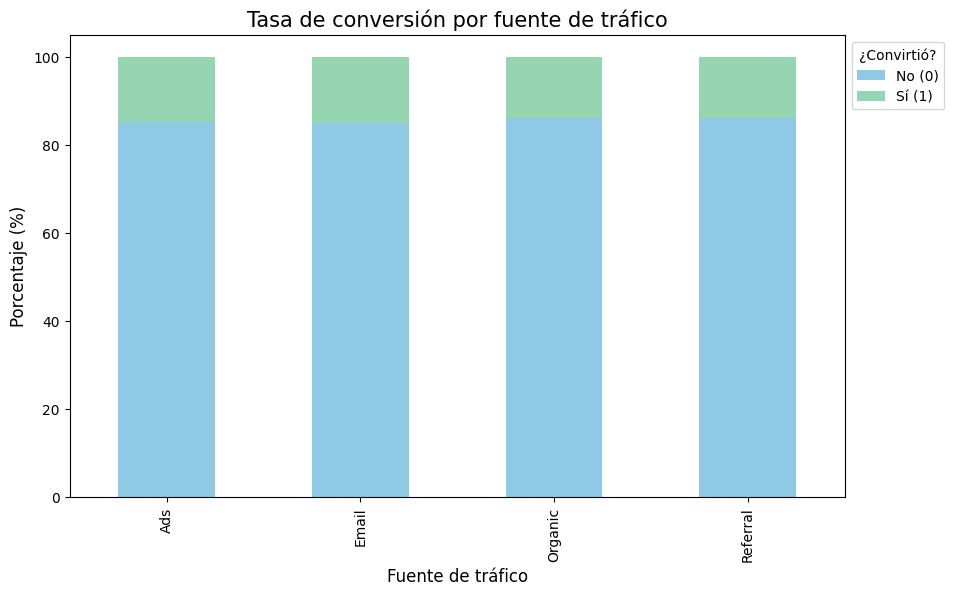

In [28]:
tabla_normalizada.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de conversión por fuente de tráfico', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Fuente de tráfico', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

El gráfico de 'Tasa de Conversión por fuente de tráfico', revela aunque el gráfico previo muestra Organic con el mayor volumen de usuarios, no es el canal más efectivo. Su franja verde (conversión) es visiblemente más delgada que la de Email, que muestra la mayor proporción de conversión 
de los cuatro canales, seguido de cerca por Ads. Organic y Referral presentan las tasas de conversión más bajas. Este gráfico es consistente con el hallazgo de la prueba chi cuadrada aunque la asociación entre fuente de tráfico y conversión es estadísticamente significativa, la diferencia 
visual entre canales es sutil, en línea con la diferencia modesta de apenas 1.2 puntos porcentuales encontrada anteriormente.

### Relación entre el tipo de usuario y la conversión

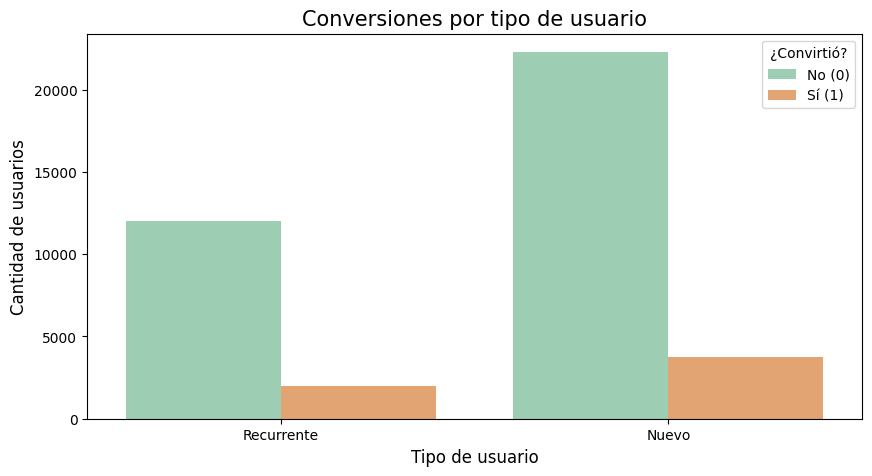

In [29]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, x='user_type', hue='converted', palette=["#95D5B2", "#F4A261"])
plt.title('Conversiones por tipo de usuario', fontsize=15)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.ylabel('Cantidad de usuarios', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'])
plt.show()

El gráfico de 'Conversiones por tipo de usuario',  muestra que el grupo de usuarios "Nuevo" es considerablemente más grande que el de "Recurrente" (aproximadamente 26,000 vs 14,000 usuarios). 
Ambos grupos, la barra de "No convirtió",domina ampliamente sobre la de "Sí convirtió", en línea con la tasa general de conversión del 14.27%.

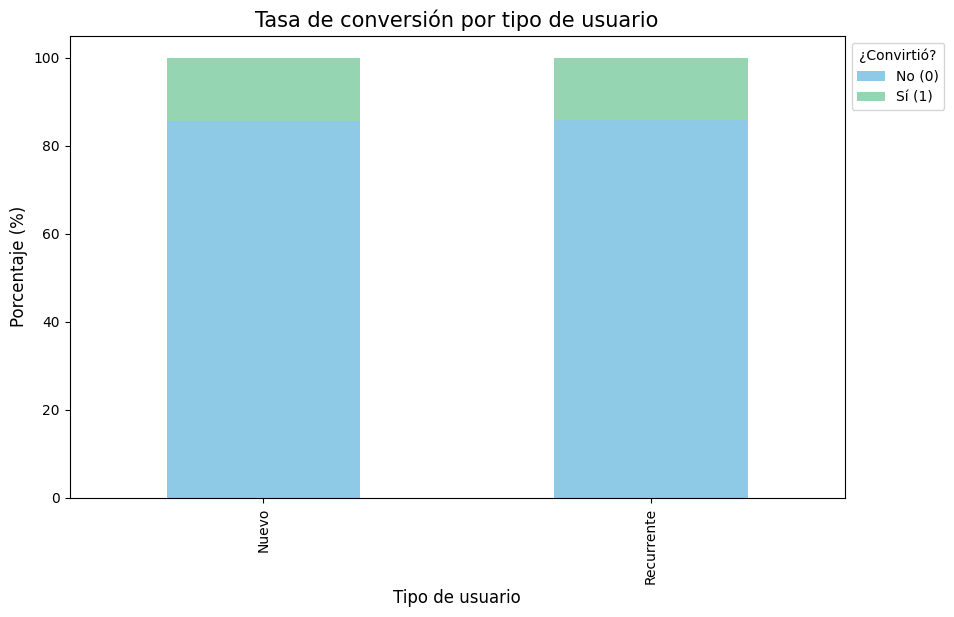

In [30]:
tabla_usuario_normalizada.plot(kind='bar', stacked=True, figsize=(10, 6), color=["#8ecae6", "#95d5b2"])
plt.title('Tasa de conversión por tipo de usuario', fontsize=15)
plt.ylabel('Porcentaje (%)', fontsize=12)
plt.xlabel('Tipo de usuario', fontsize=12)
plt.legend(title='¿Convirtió?', labels=['No (0)', 'Sí (1)'], loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

El gráfico de 'Tasa de conversión por tipo de usuario', la franja verde (conversión) tiene un grosor muy similar tanto para usuarios nuevos como recurrentes. 
Esto confirma visualmente el resultado de la prueba chi cuadrada donde el valor p = 0.474, no existe una diferencia real en la tasa de conversión entre estos dos segmentos.
En este gráfico se muestraa que el tipo de usuario no aporta una señal distintiva sobre la probabilidad de conversión.

## 🧩 Paso 7. Insight Ejecutivo para Stakeholders

Se traducen los hallazgos del análisis del experimento A/B en conclusiones accionables para el negocio, enfocadas en **versión de página, conversión, gasto promedio, canales de tráfico y tipo de usuario**.

**Preguntas a responder:**  
- ¿Qué página genera mayor conversión y gasto promedio?  
- ¿Qué canales de tráfico son más efectivos para generar conversiones?  
- ¿Existen diferencias significativas según el tipo de usuario?  
- ¿Qué recomendaciones se pueden tomar para optimizar la estrategia de marketing?


---

### 🌟 Insight Ejecutivo basado en el Experimento A/B

#### 🔍 **Comparación de página (A vs B)**  

**Gasto promedio por usuario que convirtió:**

- La página B tiene un gasto promedio de 68.75 por usuario convertido, frente a 61.09 de la página A con una diferencia de 7.66 a favor de la página B.
  
- La prueba t confirma que esta diferencia es significativa (t = -9.366, valor p < 0.001).

- **Interpretación:**

Los usuarios que convierten a través de la página B no solo son más numerosos, sino que también generan mayor valor económico por transacción.

**Tasa de conversión:** 

- La página B convierte al 15.96% de sus usuarios, frente al 12.57% de la página A con una diferencia de 3.4 puntos porcentuales.
  
- La prueba z confirma que esta diferencia es estadísticamente significativa (z = -9.677, valor p < 0.001).

- **Interpretación:**

La página B es superior a la página A en ambas métricas clave del negocio como lo es la conversión y gasto promedio.

---

#### 📊 **Segmentación por fuente de tráfico**

- Existe una asociación estadísticamente significativa entre el canal de tráfico y la conversión (Chi cuadrada = 8.662, valor p = 0.034), aunque existe una ligera diferencia entre Email (14.99%) y Ads (14.74%) como la diferencia entre Organic (13.79%) y Referral (13.88%).
  
- **Interpretación:**

El canal de tráfico tiene un impacto real pero pequeño en la conversión ya que no es un factor prioritario, pero sí puede usarse como criterio secundario de optimización.

 ---

#### 📊 **Segmentación por tipo de usuario**

- No existe una asociación estadísticamente significativa entre el tipo de usuario y la conversión (Chi cuadrada = 0.513, valor p = 0.474). Usuarios nuevos (14.36%) y recurrentes (14.09%) convierten de forma idéntica.
  
- **Interpretación:**

El tipo de usuario no es un factor relevante para explicar diferencias en conversión dentro de este experimento.

---

Las visualizaciones usadas respaldan los resultados estadísticos de pasos anteriores.

---

#### 💡 **Recomendaciones de negocio:** 

- Implementar la página B como versión definitiva de la landing page, ya que supera consistentemente a la página A tanto en tasa de conversión como en gasto promedio por usuario convertido, con evidencia estadística sólida en ambas métricas.
- Priorizar moderadamente inversión en los canales Email y Ads sobre Organic y Referral, dado que muestran mayor tasa de conversión, aunque la diferencia es pequeña y no debe ser el criterio principal de asignación de presupuesto.
- No es necesario diseñar estrategias diferenciadas por tipo de usuario (nuevo vs recurrente), ya que no se encontró ninguna diferencia significativa en su comportamiento de conversión.
- Se recomienda dar seguimiento al impacto de implementar la página B a largo plazo, y considerar pruebas A/B  adicionales sobre otros elementos de la página para continuar optimizando la conversión.